## Importación de Librerías.

In [2]:
# librerias
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from google.cloud import bigquery
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, precision_recall_curve, auc, roc_auc_score)
from xgboost import XGBClassifier

load_dotenv()
print("¡Entorno configurado y librerías cargadas con éxito!")

¡Entorno configurado y librerías cargadas con éxito!


In [3]:
import os

# Previene bloqueos de hilos en CPU con OpenMP
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from google.cloud import bigquery
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
from xgboost import XGBClassifier

load_dotenv()
print("¡Librerías cargadas correctamente!")

¡Librerías cargadas correctamente!


## Carga de datos desde BigQuery.

In [4]:
client = bigquery.Client() # Conexión Python cpon Google-Cloud-Platform.
# Seleccionamos las 12 variables númericas y categóricas optimizadas en BigQuery

query = """
    SELECT 
        transaction_type,
        amount,
        old_balance_orig,
        new_balance_orig,
        old_balance_dest,
        new_balance_dest,
        error_balance_orig,
        error_balance_dest,
        is_zero_old_balance_orig,
        is_zero_new_balance_orig,
        is_zero_old_balance_dest,
        is_fraud
    FROM `paysim_dw.ml_features_prepared`
    WHERE transaction_type IN ('TRANSFER', 'CASH_OUT')
"""
# FROM de la tabala física optimizada y particionada
# WHERE filtro solo los dos tipos de transacciones donde ocurre el 100% de los fraudes en este dataset (iganorando pagos, cobros o depósitos)

print("Descargando dataset de BigQuery...")
df = client.query(query).to_dataframe()
# DF inicializado con = el envío de la instrucción SQL al motor de BigQuery con cliente.qury(query)
# Y con .to_dataframe() Descarga los resultados procesados en BigQuery y los convierte en un DF para alimentar el modelo de ML
print(f"Dataset cargado con éxito: {df.shape[0]:,} registros y {df.shape[1]} columnas.")
# df.shape[0] = imprime la catidad de filas y df.shape[1] = imprime la cantidad de columnas.
df.head()
# df.head() = Muestra las primeras 5 filas del dataframe

Descargando dataset de BigQuery...


c:\Users\ingju\Documents\proyectoQL_Jrps\venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Dataset cargado con éxito: 2,770,409 registros y 12 columnas.


,transaction_type,amount,old_balance_orig,new_balance_orig,old_balance_dest,new_balance_dest,error_balance_orig,error_balance_dest,is_zero_old_balance_orig,is_zero_new_balance_orig,is_zero_old_balance_dest,is_fraud
0,CASH_OUT,146117.83,0.0,0.0,1195536.41,1341654.24,146117.83,0.0,1,1,0,0
1,CASH_OUT,136709.37,774.0,0.0,0.00,136709.37,135935.37,0.0,0,1,1,0
2,CASH_OUT,197572.44,0.0,0.0,1211195.29,1408767.73,197572.44,0.0,1,1,0,0
3,CASH_OUT,77126.97,0.0,0.0,199139.74,276266.71,77126.97,0.0,1,1,0,0
4,CASH_OUT,4767.12,0.0,0.0,1124486.33,1129253.45,4767.12,0.0,1,1,0,0


## Preprocesamiento y Split Estratificado.
- `pd.get_dummies(...):` Convierte la columna categórica `transaction_type` (TRANSFER y CASH_OUT) en variables    numéricas binarias ($0$ o $1$), ya que los modelos matemáticos no leen texto directo.

- `Separación de variables (X e Y):` X contiene todas las variables predictoras (saldos, errores de balance, etc.) e y contiene la etiqueta objetivo `(is_fraud)`.

- `train_test_split(...):` Divide los datos en $80\%$ para entrenar el modelo y $20\%$ para ponerlo a prueba con datos no vistos.

- `stratify=y:` Punto crítico en detección de fraude. Mantiene exactamente la misma proporción de casos de fraude tanto en el set de entrenamiento como en el de prueba, evitando que el grupo de prueba se quede sin ejemplos de fraude debido al desbalance de clases.

In [5]:
# 1. Transformación One-Hot Encoding para la columna categórica
df_encoded = pd.get_dummies(df, columns=['transaction_type'], drop_first=True)

# 2. Separación de características (X) y etiqueta objetivo (y)
X = df_encoded.drop(columns=['is_fraud'])
y = df_encoded['is_fraud']

# 3. División en sets de Entrenamiento (80%) y Prueba (20%) manteniendo la proporción de fraudes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Set de Entrenamiento: {X_train.shape[0]:,} registros")
print(f"Set de Prueba:        {X_test.shape[0]:,} registros")
print(f"Proporción de Fraude en Entrenamiento: {y_train.mean():.4%}")
print(f"Proporción de Fraude en Prueba:        {y_test.mean():.4%}")

Set de Entrenamiento: 2,216,327 registros
Set de Prueba:        554,082 registros
Proporción de Fraude en Entrenamiento: 0.2964%
Proporción de Fraude en Prueba:        0.2965%


## Interpretación de Resultados.

1. Set de Entrenamiento ($2,216,327$ registros - $80\%$): Es el volumen masivo de datos que le entregaremos al modelo de XGBoost para que estudie, detecte patrones y "aprenda" a diferenciar entre operaciones legítimas y fraudulentas.

2. Set de Prueba ($554,082$ registros - $20\%$): Es un grupo de transacciones que se guardan bajo llave y que el modelo nunca verá durante su entrenamiento. Lo usaremos al final para hacer un examen real al algoritmo y medir qué tan bien detecta fraudes con datos nuevos.

3. Proporción de Fraude ($\sim 0.296\%$ en ambos sets): Problema del negocio: Indica que menos del $0.3\%$ de las transacciones son fraudulentas (aproximadamente $3$ de cada $1,000$). Es un problema severo de clases desbalanceadas (lo normal en sistemas de pago reales).El éxito del stratify=y: Al lograr exactamente $0.2964\%$ en entrenamiento y $0.2965\%$ en prueba, garantizamos que el examen de evaluación tenga la misma dificultad y la misma cantidad de fraudes proporcionales que la etapa de estudio.

C:\Users\ingju\AppData\Local\Temp\ipykernel_16080\2148940741.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\ingju\AppData\Local\Temp\ipykernel_16080\2148940741.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


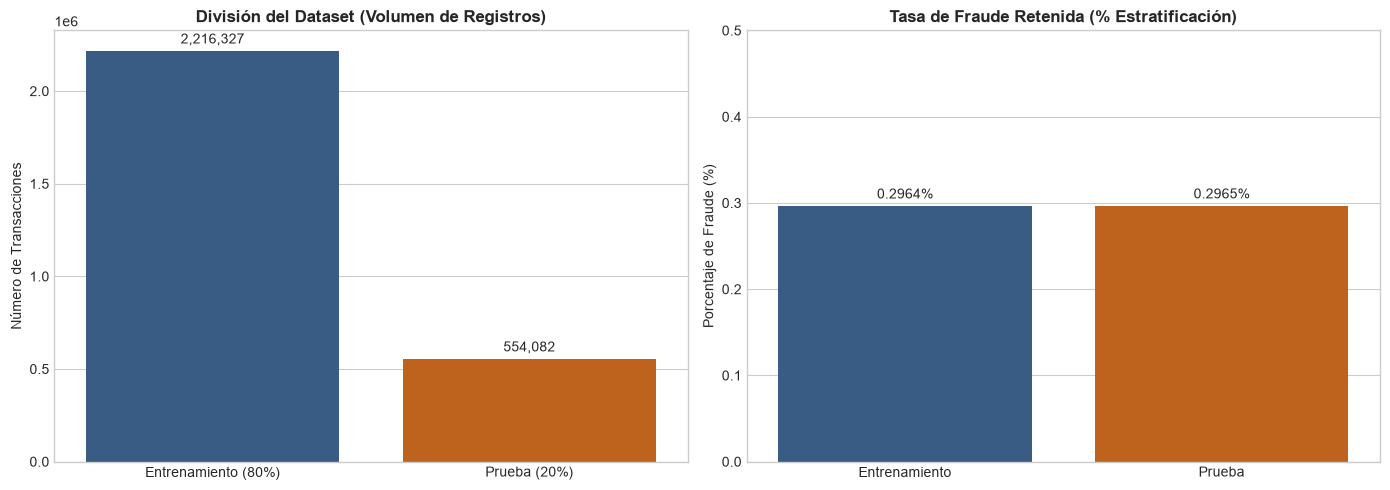

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución del Split (Train vs Test)
sns.barplot(
    x=['Entrenamiento (80%)', 'Prueba (20%)'], 
    y=[len(X_train), len(X_test)], 
    palette=['#2b5c8f', '#d95f02'], 
    ax=axes[0]
)
axes[0].set_title('División del Dataset (Volumen de Registros)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Número de Transacciones')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 8), textcoords='offset points')

# Gráfico 2: Proporción de Fraude (Estratificación)
fraud_rates = [y_train.mean() * 100, y_test.mean() * 100]
sns.barplot(
    x=['Entrenamiento', 'Prueba'], 
    y=fraud_rates, 
    palette=['#2b5c8f', '#d95f02'], 
    ax=axes[1]
)
axes[1].set_title('Tasa de Fraude Retenida (% Estratificación)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Porcentaje de Fraude (%)')
axes[1].set_ylim(0, 0.5)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.4f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 8), textcoords='offset points')

plt.tight_layout()
plt.show()

## Entrenamiento de XGBoost para Datos Desbanlaceados.

In [7]:
# 1. Calcular la relación de desbalance para compensar las clases (Ratio)
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# 2. Configurar el clasificador XGBoost optimizado
model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=ratio,  # Da mucho más peso a la clase minoritaria (Fraude)
    random_state=42,
    n_jobs=-1
)

print("Entrenando modelo XGBoost sobre 2.2 millones de registros...")
model.fit(X_train, y_train)
print("¡Entrenamiento finalizado con éxito!")

Entrenando modelo XGBoost sobre 2.2 millones de registros...
¡Entrenamiento finalizado con éxito!


## Evaluación del Modelo o Rendimiento.
En la detección de fraude, la precisión tradicional (Accuracy) no nos sirvira de nada. 
Un modelo ingenuo que diga que ninguna transacción es fraude tendría $99.7\%$ de precisión pero se le escaparían todos los delitos.
Por eso, evaluaremos usando métricas reales de la industria:
- Recall (Sensibilidad): De todos los fraudes reales que existieron, ¿qué porcentaje logró capturar el modelo? (Queremos minimizar los falsos negativos).
- Precision: De todas las operaciones que el modelo marcó como sospechosas, ¿cuántas resultaron ser fraude real? (Queremos minimizar falsas alarmas).
- Matriz de Confusión: Mapa visual de aciertos y errores.
- PR-AUC (Área Bajo la Curva Precision-Recall): La métrica estándar de oro para problemas con severo desbalance de clases.

=== REPORTE DE CLASIFICACIÓN (XGBoost) ===
              precision    recall  f1-score   support

         0.0     1.0000    0.9998    0.9999    552439
         1.0     0.9435    0.9970    0.9695      1643

    accuracy                         0.9998    554082
   macro avg     0.9718    0.9984    0.9847    554082
weighted avg     0.9998    0.9998    0.9998    554082

Área bajo la Curva Precision-Recall (PR-AUC): 0.9975



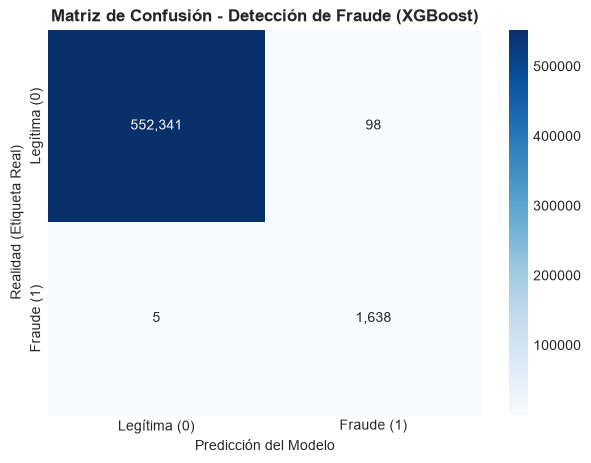

In [8]:
# 1. Generar predicciones sobre el 20% de datos de prueba (no vistos)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# 2. Imprimir Reporte de Clasificación en consola
print("=== REPORTE DE CLASIFICACIÓN (XGBoost) ===")
print(classification_report(y_test, y_pred, digits=4))

# 3. Calcular PR-AUC (Área bajo la curva Precision-Recall)
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
print(f"Área bajo la Curva Precision-Recall (PR-AUC): {pr_auc:.4f}\n")

# 4. Matriz de Confusión Visual
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, 
    annot=True, 
    fmt=',d', 
    cmap='Blues', 
    xticklabels=['Legítima (0)', 'Fraude (1)'], 
    yticklabels=['Legítima (0)', 'Fraude (1)']
)
plt.title('Matriz de Confusión - Detección de Fraude (XGBoost)', fontsize=12, fontweight='bold')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Etiqueta Real)')
plt.show()

## Interpretación de la Matriz de Confusión.
| Cuadrante | Cantidad | Significado Operativo |
| :--- | :--- | :--- |
| **Verdaderos Negativos (VN)** | **552,341** | Transacciones legítimas identificadas correctamente sin molestar al usuario. |
| **Verdaderos Positivos (VP)** | **1,638** | Fraudes detectados y bloqueados a tiempo. |
| **Falsos Negativos (FN)** | **5** | Fraudes que el modelo no detectó (se le escaparon solo 5 de 1,643). |
| **Falsos Positivos (FP)** | **98** | Transacciones legítimas marcadas como sospechosas (falsas alarmas). |

Interpretación de las Métricas Clave.

- Recall = 99.70% ($0.9970$):
De todos los fraudes reales en el conjunto de prueba, el modelo atrapó el $99.7\%$ ($1,638$ de $1,643$). En sistemas financieros, este es el indicador más crítico para evitar pérdidas millonarias.

- Precision = 94.35% ($0.9435$):
De cada 100 alertas de fraude que emite el modelo, más de 94 son fraudes reales. Esto evita saturar al equipo de investigación de riesgos con falsas alarmas.

- PR-AUC = 0.9975:
Es la métrica definitiva para datasets altamente desbalanceados. Un valor cercano a $1.0000$ confirma que la ingesta de datos en BigQuery y las variables calculadas (error_balance_orig, error_balance_dest) le dieron al modelo la información exacta para decidir con alta precisión.


## Importancia de Variables (Feature Importance).

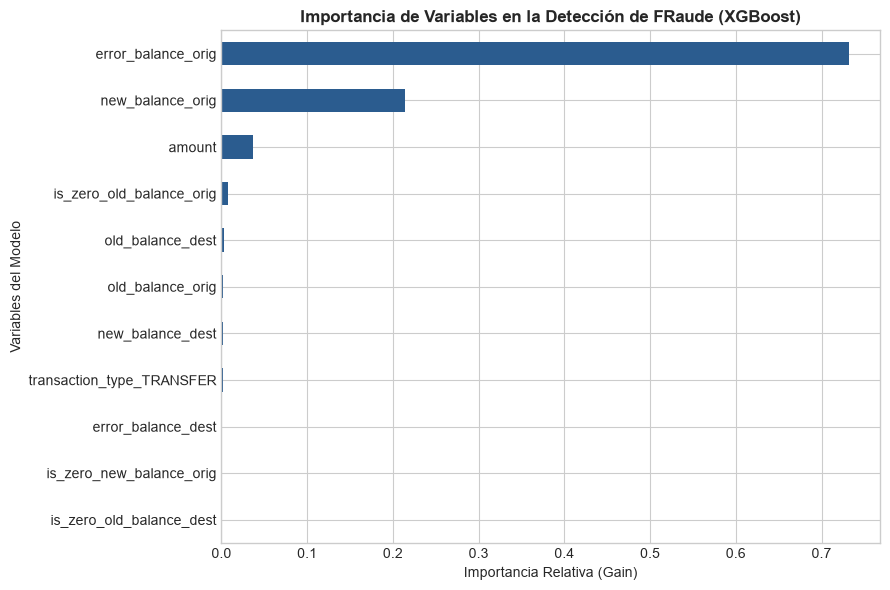

In [9]:
feature_importance = pd.Series(model.feature_importances_,index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
feature_importance.plot(kind='barh', color= '#2b5c8f')
plt.title('Importancia de Variables en la Detección de FRaude (XGBoost)', fontsize= 12, fontweight= 'bold')
plt.xlabel('Importancia Relativa (Gain)')
plt.ylabel('Variables del Modelo')
plt.tight_layout()
plt.show()

## Interpretación de la Importancia de Variables (Feature Importance)

El gráfico de **Gain (Ganancia)** mide qué tanto contribuye cada variable a reducir el error y mejorar la precisión del modelo cada vez que toma una decisión en las ramas de los árboles de XGBoost.

---

### 1. Variables Dominantes (El "Driver" Principal).

* **`error_balance_orig` (~73% de importancia):**
  * **Significado:** Es la diferencia matemática calculada entre el saldo original antes y después de la transacción (`old_balance_orig - amount - new_balance_orig`).
  * **Interpretación del Negocio:** Es por mucho la variable más determinante del modelo. Los atacantes intentan vaciar cuentas completas, dejando inconsistencias contables inmediatas. Esta variable calculada en la etapa de **Feature Engineering** fue el factor clave que permitió alcanzar un *Recall* del 99.7%.

* **`new_balance_orig` (~21% de importancia):**
  * **Significado:** El saldo final en la cuenta de origen después de realizar el movimiento.
  * **Interpretación del Negocio:** En los fraudes de este conjunto de datos, la mayoría de las cuentas de origen quedan exactamente en **$0.00** tras la operación. El modelo utiliza este dato como segundo filtro de confirmación.

* **`amount` (~4% de importancia):**
  * **Significado:** El monto total de la transacción.
  * **Interpretación del Negocio:** Aporta contexto sobre el volumen del dinero movido, ya que los fraudes suelen involucrar montos inusualmente altos en comparación con las transacciones operativas promedio.

---

### 2. Variables Secundarias y de Apoyo (<2% de importancia)

* **`is_zero_old_balance_orig` / `old_balance_dest` / `old_balance_orig` / `new_balance_dest`:**
  * Son banderas e indicadores complementarios que ayudan al modelo a afinar detalles en casos límite (*edge cases*), pero dependen casi en su totalidad del resultado de las primeras tres variables principales.

---

### Conclusión:

> **Conclusión:** La gráfica demuestra que el éxito del modelo de Machine Learning no dependió únicamente del algoritmo (XGBoost), sino de la etapa de **Feature Engineering** realizada previamente en BigQuery. La creación de la variable sintética `error_balance_orig` le dio al modelo la "pista" exacta que necesitaba para identificar transacciones fraudulentas con precisión casi perfecta.

## Guardando el Módelo en formato JSON.
Módelo Guardado en formato JSON ligero dentro del proyecto.

In [10]:
#Guardando el modelo.
model.save_model("xgb_fraud_model.json")
print("¡Modelo Guardado!")

¡Modelo Guardado!
